# From Perceptron to Deep Networks: Why Hidden Layers Matter

**Student ID:** 24152801  
**Module:** Machine Learning and Neural Networks  
**Github Link:** https://github.com/Bhavesh2618/Machine-Learning-Tutorial-24152801

---

This notebook demonstrates how neural network performance changes when moving from a perceptron (no hidden layers) to shallow and deep neural networks.

In [ ]:
# Install packages if needed
!pip install tensorflow scikit-learn matplotlib pandas
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # hides TF warnings

import warnings
warnings.filterwarnings("ignore")

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import set_random_seed

# Fix retracing warning
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
# Reproducibility
np.random.seed(42)
set_random_seed(42)

## Dataset

The Breast Cancer dataset from scikit-learn is used in this experiment.

- Total samples: 569  
- Features: 30 numerical features  
- Classes:
  - Malignant (0)
  - Benign (1)

This dataset is widely used for binary classification tasks.

## Data Preprocessing

The dataset is split into training and testing sets using an 80/20 ratio.  
Feature scaling is applied using StandardScaler to ensure all features contribute equally to the model.

In [46]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print("Dataset shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("Class names:", data.target_names)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Dataset shape: (569, 30)
Number of classes: 2
Class names: ['malignant' 'benign']
Training shape: (455, 30)
Testing shape: (114, 30)


## Model Design

Three models are implemented:

1. **Perceptron-like model**
   - No hidden layers
   - Acts as a linear classifier

2. **Shallow MLP**
   - One hidden layer (16 neurons)

3. **Deep MLP**
   - Two hidden layers (32 and 16 neurons)

All models use:
- ReLU activation (hidden layers)
- Sigmoid activation (output)
- Adam optimizer
- Binary crossentropy loss

In [47]:
# Build models
def build_model(hidden_layers):
    model = Sequential()

    # No hidden layer: perceptron-like model
    if len(hidden_layers) == 0:
        model.add(Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)))
    else:
        model.add(Dense(hidden_layers[0], activation='relu', input_shape=(X_train.shape[1],)))
        for units in hidden_layers[1:]:
            model.add(Dense(units, activation='relu'))
        model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [48]:
# Define architectures
architectures = {
    "Perceptron_like": [],
    "Shallow_MLP": [16],
    "Deep_MLP": [32, 16]
}

histories = {}
trained_models = {}
results = []

## Model Training

Each model is trained for 50 epochs using the same dataset and parameters.  
This ensures a fair comparison where only the architecture differs.

In [49]:
# Train all models
for name, hidden_layers in architectures.items():
    print(f"Training {name} with hidden layers = {hidden_layers}")

    model = build_model(hidden_layers)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=16,
        verbose=0
    )

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)

    histories[name] = history
    trained_models[name] = model
    results.append({
        "Model": name,
        "Hidden Layers": str(hidden_layers),
        "Test Accuracy": acc
    })

    print(f"{name} Test Accuracy: {acc:.4f}\n")

Training Perceptron_like with hidden layers = []
Perceptron_like Test Accuracy: 0.9649

Training Shallow_MLP with hidden layers = [16]
Shallow_MLP Test Accuracy: 0.9649

Training Deep_MLP with hidden layers = [32, 16]
Deep_MLP Test Accuracy: 0.9561



## Results Section

In [50]:
# Results table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
results_df

,Model,Hidden Layers,Test Accuracy
0,Perceptron_like,[],0.964912
1,Shallow_MLP,[16],0.964912
2,Deep_MLP,"[32, 16]",0.956140


## Plotting Sections

## Different line styles are used in plots to ensure that information is distinguishable without relying solely on colour.

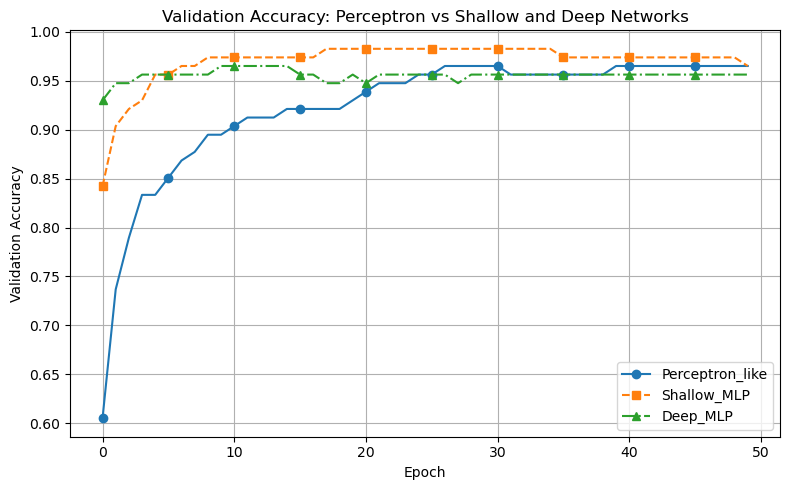

In [53]:
plt.figure(figsize=(8, 5))

styles = ['-', '--', '-.']  # line styles for accessibility
markers = ['o', 's', '^']   # optional markers

for (name, history), style, marker in zip(histories.items(), styles, markers):
    plt.plot(
        history.history["val_accuracy"],
        linestyle=style,
        marker=marker,
        markevery=5,   # reduces clutter
        label=name
    )

plt.title("Validation Accuracy: Perceptron vs Shallow and Deep Networks")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()  # improves spacing
plt.show()

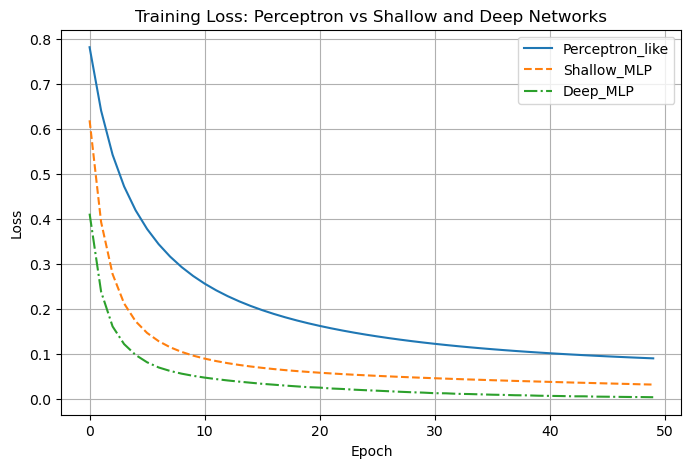

In [52]:
plt.figure(figsize=(8, 5))

styles = ['-', '--', '-.']  # different line styles

for (name, history), style in zip(histories.items(), styles):
    plt.plot(history.history["loss"], linestyle=style, label=name)

plt.title("Training Loss: Perceptron vs Shallow and Deep Networks")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

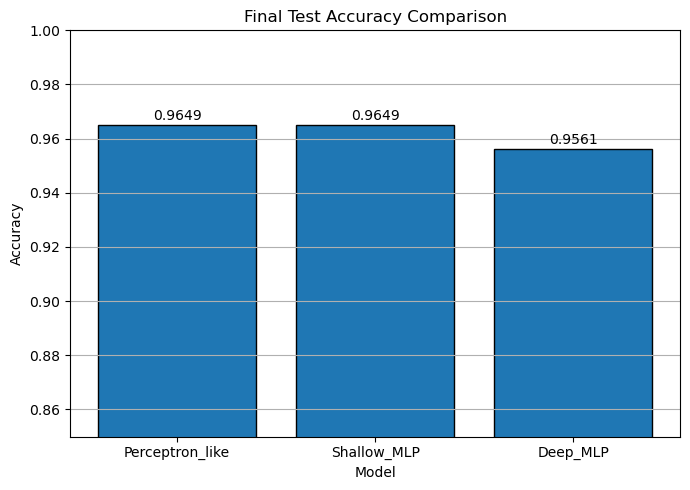

In [55]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    results_df["Model"],
    results_df["Test Accuracy"],
    edgecolor='black'   # adds clear borders
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f"{height:.4f}",
        ha='center',
        fontsize=10
    )

plt.title("Final Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.ylim(0.85, 1.00)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

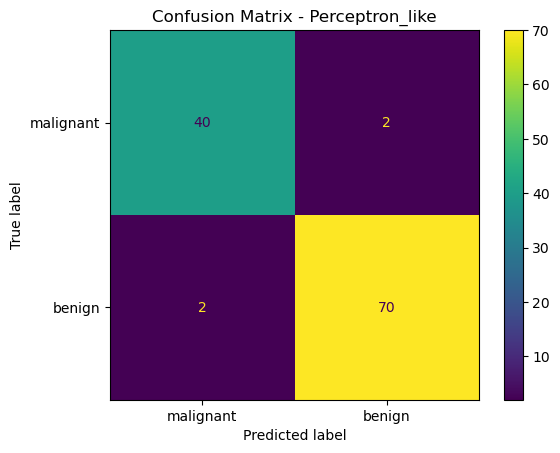

Classification Report for Perceptron_like
              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



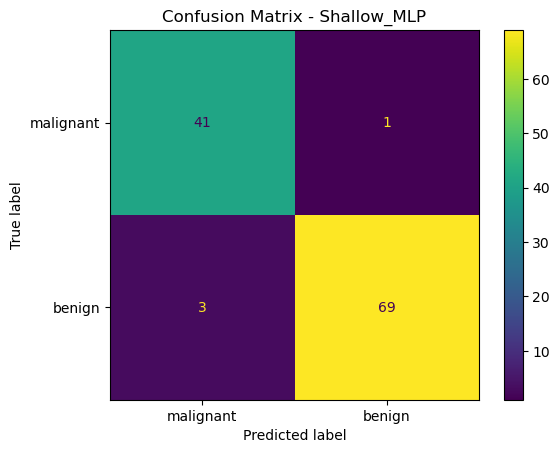

Classification Report for Shallow_MLP
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



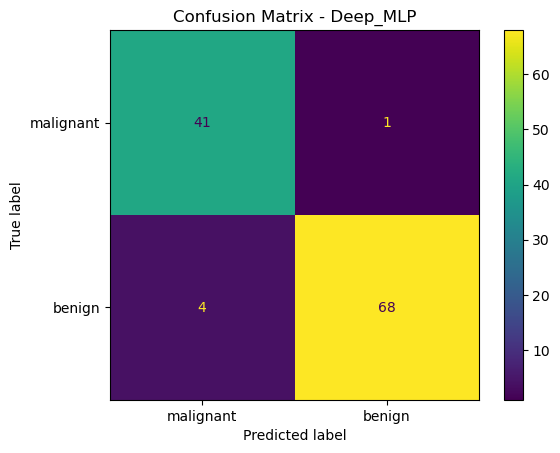

Classification Report for Deep_MLP
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [39]:
# Confusion matrix for each model
for name, model in trained_models.items():
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    print(f"Classification Report for {name}")
    print(classification_report(y_test, y_pred, target_names=data.target_names))

## Conclusion

This tutorial demonstrates that hidden layers play a crucial role in enabling non-linear learning in neural networks. While they significantly enhance model flexibility, they do not always lead to improved performance.

The results indicate that simpler models can perform effectively on structured datasets, where the underlying relationships are relatively straightforward. In contrast, deeper and more complex networks are better suited for problems involving higher levels of complexity.

Therefore, hidden layers are essential for expanding the learning capacity of neural networks; however, the optimal depth of a model should be determined based on the characteristics of the data rather than assumed by default.